In [1]:
import numpy as np
import finufft
import matplotlib.pyplot as pl
from scipy.interpolate import CubicSpline
import copy

pi = np.pi

## beta

In [2]:
def t_max_calc(f0, beta, f_max):
    temp0 = 0.375/beta
    temp1 = 1-(f0/f_max)**(8/3)
    return temp0*temp1

In [3]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

f0 = 20
Mc = 3e-2* 2e30
f_max = 200
beta = const*f0**(8/3)*Mc**(5/3)
T_obs = min(1e4, t_max_calc(f0, beta, 200))
# pad_len = int(340*T_obs) #~0.01 added length to resampled data
f_signal = 40*f_max
nt = round(f_signal*T_obs)
t = (np.arange(nt)/f_signal)#.astype(np.longdouble)
f_ratio = 25

phi = -6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta
# phi = np.mod(phi,2*pi)
signal = 1*np.exp(1j*phi)
signal_window = copy.deepcopy(signal)
signal_window[:int(5e2)] = np.zeros((int(5e2)))
signal_window[-int(5e2):] = np.zeros((int(5e2)))

In [4]:
beta

4.973205568156829e-06

In [5]:
def strobo(beta, data, f_ratio):
    new_t = -3/5*(1-8/3*beta*t)**(5/8)/beta
    f_new = f_signal/f_ratio
    
    new_t *= f_new #changes the frequency to the new downsampled frequency (approximately, not exactly)
    floor_t = np.floor(new_t) #For some reason floor works better than round. Take it to the nearest time index which are integers
    idx = np.nonzero(np.diff(floor_t)) #The step that downsamples
    resampled = data[idx]
    t_out = (new_t[idx]-new_t[0])/f_new
    return (resampled, t_out)

In [6]:
f_ratio = 25
out, t_out = strobo(beta, signal, f_ratio)
corrected = np.fft.fftshift(np.fft.fft(out))
freq_corrected = np.fft.fftshift(np.fft.fftfreq(len(t_out), d=t_out[1]-t_out[0]))
corrected = corrected/len(out)
resampled_power = np.abs(corrected)**2

freq_corrected = freq_corrected
nt_new = len(out)

In [7]:
tau = -3/5*(1-8/3*beta*t)**(5/8)/beta
scale = (2*pi)/(tau[-1]-tau[0])
tau *= scale
start_diff = -pi-tau[0]
tau += start_diff

In [13]:
bin_no = int(len(resampled_power))
bins = np.arange(bin_no) - bin_no//2

nufft_freq_win = -bins*scale/(2*pi)
f_win = finufft.nufft1d1(tau.astype(np.float64), signal_window.astype(complex), bin_no)
nufft_power_win = abs(f_win/len(signal_window))**2

nufft_freq = -bins*scale/(2*pi)
f = finufft.nufft1d1(tau.astype(np.float64), signal.astype(complex), bin_no)
nufft_power = abs(f/len(signal))**2

found = nufft_freq[np.argmax(nufft_power)]
print('Maximum power at f = %.2f' % (found))

Maximum power at f = 20.00


In [ ]:
# fig, axs = pl.subplots(ncols = (2), figsize=(16, 6))

# axs[0].plot(freq_corrected, np.real(corrected), 'o', label='Real')
# axs[0].plot(freq_corrected, np.imag(corrected), 'o', label="Imaginary")
# axs[0].set_xlim(19.995, 20.005)
# axs[0].set_title('Fourier spectrum of stroboscopic resampling')
# axs[0].legend()

# axs[1].plot(nufft_freq, np.real(f/len(signal)), 'o', label='Real')
# axs[1].plot(nufft_freq, np.imag(f/len(signal)), 'o', label='Imaginary')
# axs[1].set_xlim(19.995, 20.005)
# axs[1].set_title('Fourier spectrum of NUFFT')
# axs[1].legend()

# fig.suptitle("NUFFT kernel function has an effect on the Fourier spectrum")

Text(0.5, 1.0, 'Power spectrum for strobo vs NUFFT')

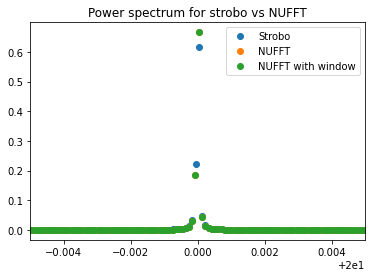

In [14]:
pl.plot(freq_corrected, resampled_power,'o', label='Strobo')
pl.plot(nufft_freq, nufft_power, 'o', label='NUFFT')
pl.plot(nufft_freq, nufft_power_win, 'o', label='NUFFT with window')
pl.xlim(19.995, 20.005)
pl.legend()
pl.title("Power spectrum for strobo vs NUFFT")

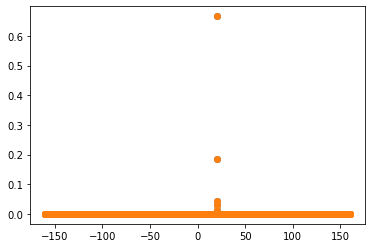

In [15]:
pl.plot(nufft_freq, nufft_power, 'o', label='NUFFT')
pl.plot(nufft_freq, nufft_power_win, 'o', label='NUFFT with window')

In [16]:
np.allclose(nufft_power_win, nufft_power, rtol=1e-2)

True

In [17]:
nufft_peak = nufft_power>np.median(nufft_power)+6*np.std(nufft_power)
nufft_peak_win = nufft_power>np.median(nufft_power_win)+6*np.std(nufft_power_win)
print(np.sum(nufft_power[nufft_peak]), np.sum(nufft_power_win[nufft_peak_win]))
print(np.isclose(np.sum(nufft_power[nufft_peak]), np.sum(nufft_power_win[nufft_peak_win])))

0.9739658006549866 0.9739604517197734
True
